<a href="https://colab.research.google.com/github/oberlinkeyanfe-ops/Completely_comparaison/blob/main/Complexity_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install rpy2
%load_ext rpy2.ipython

# Installation des packages R nécessaires
!Rscript -e 'if(!requireNamespace("remotes")) install.packages("remotes"); remotes::install_github("animint/animint2")'
!Rscript -e 'install.packages("atime", repos="https://cloud.r-project.org")'

In [4]:
# 1. Installation de animint2 et directlabels via Rscript (à exécuter dans Colab)
!Rscript -e 'if(!requireNamespace("remotes")) install.packages("remotes"); remotes::install_github("animint/animint2")'
!Rscript -e 'install.packages(c("atime", "directlabels"), repos="https://cloud.r-project.org")'

Loading required namespace: remotes
Skipping install of 'animint2' from a github remote, the SHA1 (426295cb) has not changed since last install.
  Use `force = TRUE` to force installation
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/atime_2026.4.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/directlabels_2026.4.23.tar.gz'
* installing *source* package ‘atime’ ...
** this is package ‘atime’ version ‘2026.4.2’
** package ‘atime’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** data
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (atime)
*

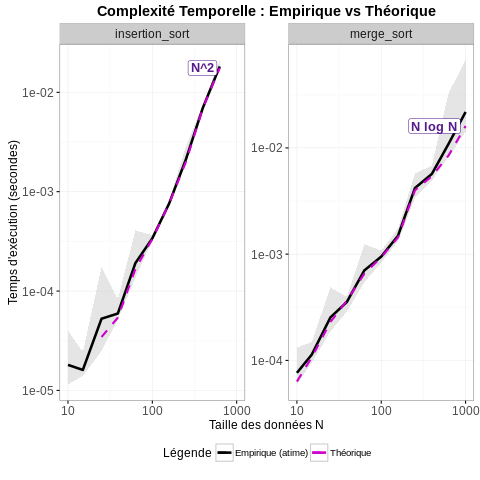

In [38]:
%%R

library(atime)
library(animint2)

# 1) Implementation of sorting algorithms
insertion_sort <- function(tab) {
  n <- length(tab)
  if (n <= 1) return(tab)
  for (i in 2:n) {
    key <- tab[i]
    j <- i - 1
    while (j>=1 && tab[j]>key) {
      tab[j +1] <- tab[j]
      j <- j -1
    }
    tab[j + 1] <- key
  }
  return(tab)
}

merge <- function(tab, start, mid, end) {
  temp <- integer(end - start + 1)
  i <- start
  j <- mid + 1
  k <- 1

  while (i<=mid && j<=end) {
    if (tab[i] <= tab[j]) {
      temp[k] <- tab[i]
      i <- i + 1
    } else {
      temp[k] <- tab[j]
      j <- j + 1
    }
    k <- k + 1
  }

  while (i <= mid) {
    temp[k] <- tab[i]
    i <- i + 1
    k <- k + 1
  }

  while (j <= end) {
    temp[k] <- tab[j]
    j <- j + 1
    k <- k + 1
  }

  k <- 1
  for (l in start:end) {
    tab[l] <- temp[k]
    k <- k + 1
  }
  return(tab)
}

merge_sort <- function(tab,start=1, end = length(tab)) {
  if (start >= end) return(tab)

  mid <- (start + end) %/% 2
  tab <- merge_sort(tab, start, mid)
  tab <- merge_sort(tab, mid + 1, end)
  tab <- merge(tab, start, mid, end)

  return(tab)
}

# 2) Benchmark execution time using atime
bench_results <- atime::atime(
  N = as.integer(10^seq(1, 3.2, by = 0.2)),
  setup = { set.seed(42); test_vec <- runif(N) },
  insertion_sort = insertion_sort(test_vec),
  merge_sort = merge_sort(test_vec,1,length(test_vec))
)

# 3 Fit asymptotic theoretical complexity models
best_references <- atime::references_best(bench_results)

meas <- best_references$measurements[unit == "seconds"]
refs <- best_references$plot.references[unit == "seconds"]

# Filter specific theoretical bounds: N^2 for insertion sort, N log N for merge sort
clean_refs <- refs[
  (expr.name == "insertion_sort" & fun.name == "N^2") |
  (expr.name == "merge_sort" & fun.name == "N log N")
]

# Extract a single endpoint label position at max N per facet
labels_df <- clean_refs[, .SD[which.max(N)], by = expr.name]

# 4 Plot empirical runtime vs theoretical complexity bounds
p <- ggplot() +
  geom_ribbon(
    aes(x = N, ymin = min, ymax = max),
    data = meas,
    fill = "grey80",
    alpha = 0.5
  ) +
  geom_line(
    aes(x = N, y = mean, color = "Empirique (atime)"),
    data = meas,
    size = 1.2
  ) +
  geom_line(
    aes(x = N, y = empirical, color = "Théorique"),
    data = clean_refs,
    linetype = "dashed",
    size = 1
  ) +
  geom_label(
    aes(x = N, y = empirical, label = fun.name),
    data = labels_df,
    fill = "white",
    color = "purple4",
    fontface = "bold",
    size = 4.5,
    hjust = 1.1,
    vjust = 0.5,
    label.padding = unit(0.2, "lines")
  ) +
  facet_wrap(~ expr.name, scales = "free_y") +
  scale_x_log10() +
  scale_y_log10() +
  scale_color_manual(values = c("Empirique (atime)" = "black", "Théorique" = "magenta3")) +
  theme_bw() +
  labs(
    title = "Complexité Temporelle : Empirique vs Théorique",
    x = "Taille des données N",
    y = "Temps d'exécution (secondes)",
    color = "Légende"
  ) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    legend.position = "bottom"
  )

print(p)